# Strategy Backtesting

**Backtesting** simulates how a trading rule would have performed on historical data. Here we implement and compare two classic systematic strategies on the universe of US **sector ETFs**, benchmarked against a buy-and-hold of SPY:

1. **Cross-sectional momentum** — hold the recent winners (12-1 and 6-3 variants)
2. **Moving-average crossover** — a trend-following timing rule

A credible backtest must avoid the usual traps: **look-ahead bias** (using information not yet available), **survivorship bias**, and ignoring **transaction costs** (modeled at 5 bps per unit turnover). We then judge the strategies not just on raw return but on a set of **risk-adjusted metrics**: Sharpe, Sortino, Calmar, Information Ratio, and Jensen's alpha.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats

import seaborn as sns
sns.set_style('whitegrid') # set the background to be Whitegrid

np.random.seed(42)

In [2]:
# Data downloading
tickers = [
    'XLK', # Technology
    'XLF', # Financials
    'XLE', # Energy
    'XLV', # Healthcare
    'XLY', # Consumer Discretionary
    'XLP', # Consumer Staples
    'XLI', # Industrials
    'XLB', # Materials
    'XLU', # Utilities
    'XLRE', # Real Estate
    'SPY' # S&P 500
]

start_date = '2016-01-01'
end_date = '2025-12-31'

print(f"Downloading {len(tickers)} tickers from {start_date} to {end_date}...")
data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']

print(f"\nData shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")

# Remove benchmark
benchmark = data['SPY'].copy()
strategy_universe = data.drop('SPY', axis=1) # removes the column labeled 'SPY'


Data shape: (2513, 11)
Date range: 2016-01-04 00:00:00 to 2025-12-30 00:00:00


## Returns, Sharpe, and the benchmark

We compute simple daily returns and summarize each sector's annualized mean, volatility, and Sharpe ratio (taking the risk-free rate as zero, so Sharpe $= \mu_{\text{ann}}/\sigma_{\text{ann}}$). Note that SPY's own Sharpe (0.87) is higher than every individual sector (excluding XLK), an early sign that diversification is hard to beat.

In [3]:
# Calculate returns
returns = strategy_universe.pct_change().dropna()
benchmark_returns = benchmark.pct_change().dropna()

print("Return Statistics (Annualized):")
print("=" * 40)
stats_df = pd.DataFrame({
    'Mean': returns.mean() * 252,
    'Volatility': returns.std() * np.sqrt(252),
    'Sharpe': (returns.mean() * 252) / (returns.std() * np.sqrt(252)) # assume the risk-free rate is zero
}).sort_values(by='Sharpe', ascending=False)
print(stats_df)

# Add benchmark
print(f"\nBenchmark (SPY):")
print(f"- Mean Return: {benchmark_returns.mean() * 252:.6f}")
print(f"- Volatility:  {benchmark_returns.std() * np.sqrt(252):.6f}")
print(f"- Sharpe:      {(benchmark_returns.mean() * 252) / (benchmark_returns.std() * np.sqrt(252)):.6f}")

Return Statistics (Annualized):
            Mean  Volatility    Sharpe
Ticker                                
XLK     0.234268    0.242452  0.966243
XLI     0.147549    0.198824  0.742108
XLY     0.149606    0.219602  0.681256
XLF     0.150703    0.223070  0.675588
XLV     0.109725    0.166369  0.659528
XLU     0.119385    0.191762  0.622568
XLB     0.117966    0.207479  0.568569
XLP     0.082640    0.146428  0.564375
XLE     0.125543    0.297823  0.421536
XLRE    0.084981    0.205961  0.412605

Benchmark (SPY):
- Mean Return: 0.156177
- Volatility:  0.180091
- Sharpe:      0.867210


## Signal 1: Cross-sectional momentum

Momentum is the empirical tendency of recent winners to keep winning. The **$k$-$s$ momentum** score is the total return from $k$ months ago to $s$ months ago, *skipping* the most recent $s$ months:

$$M_{k\text{-}s}(t) = \frac{P_{t-s}}{P_{t-k}} - 1.$$

The skip deliberately excludes the very recent past to sidestep the short-term reversal effect. Each rebalance we rank the sectors by this score and hold the **top 3** equal-weighted. We test two lookbacks: the classic **12-1** and a shorter **6-3**.

In [4]:
# Classic momentum strategies:
# - 12-1 momentum: return from 12 months ago to 1 month ago (skip last month)
# - 6-3 momentum: return from 6 months ago to 3 months ago

def calculate_momentum(prices, lookback, skip=0):
    """
    Calculate momentum signal.
    
    Parameters:
    prices: DataFrame of prices
    lookback: Number of periods to look back
    skip: Number of recent periods to skip
    
    Returns:
    DataFrame of momentum scores (returns over lookback period)
    """
    if skip > 0:
        momentum = prices.shift(skip) / prices.shift(lookback + skip) - 1
    else:
        momentum = prices / prices.shift(lookback) - 1
    return momentum

# Calculate momentum signals
# 12-1: 252 trading days ≈ 12 months, skip 21 days ≈ 1 month
momentum_12_1 = calculate_momentum(strategy_universe, lookback=252, skip=21)

# 6-3: 126 trading days ≈ 6 months, skip 63 days ≈ 3 months
momentum_6_3 = calculate_momentum(strategy_universe, lookback=126, skip=63)

In [5]:
# Momentum signal generator
def rank_momentum(momentum_scores, top_n=3):
    """
    Rank securities by momentum and select top N.
    
    Parameters:
    momentum_scores: DataFrame of momentum scores
    top_n: Number of top securities to select
    
    Returns:
    DataFrame of binary signals (1 if selected, 0 otherwise)
    """
    signals = pd.DataFrame(0, index=momentum_scores.index, columns=momentum_scores.columns)
    
    for date in momentum_scores.index:
        # Rank by momentum score
        scores = momentum_scores.loc[date].dropna()
        if len(scores) > 0:
            # Select top N
            top_securities = scores.nlargest(top_n).index # get the column indexes of the top 3 values in the row 'scores'
            signals.loc[date, top_securities] = 1
    
    return signals

# Generate trading signals (select top 3 each period)
signals_12_1 = rank_momentum(momentum_12_1, top_n=3)
signals_6_3 = rank_momentum(momentum_6_3, top_n=3)

print("Momentum signals generated.")
print(f"\n12-1 Signals (last 5 rows):")
print(signals_12_1.tail())

Momentum signals generated.

12-1 Signals (last 5 rows):
Ticker      XLB  XLE  XLF  XLI  XLK  XLP  XLRE  XLU  XLV  XLY
Date                                                         
2025-12-23    0    0    0    0    1    0     0    1    1    0
2025-12-24    0    0    0    0    1    0     0    1    1    0
2025-12-26    0    0    0    0    1    0     0    1    1    0
2025-12-29    0    0    0    0    1    0     0    1    1    0
2025-12-30    0    0    0    0    1    0     0    1    1    0


## Signal 2: Moving-average crossover

This is a **trend-following** timing rule based on two simple moving averages (SMAs). Hold a position while the short-window average sits above the long-window one, and exit otherwise:

$$\text{signal}_t = \mathbb{1}\big[\,\text{SMA}_{\text{short}}(t) > \text{SMA}_{\text{long}}(t)\,\big].$$

The upward cross (short above long) is the bullish **"golden cross"**; the downward cross is the bearish **"death cross."** We use the classic **50/200-day** pair. Unlike momentum, this is applied *per security independently* (each ETF is in or out on its own trend), so the number of held positions varies over time.

In [6]:
# Moving average crossover
# - Buy when short MA crosses above long MA (golden cross)
# - Sell when short MA crosses below long MA (death cross)
# - Common pairs: 50/200 day, 20/50 day

def ma_crossover_signals(prices, short_window=50, long_window=200):
    """
    Generate signals based on moving average crossover.
    
    Parameters:
    prices: DataFrame of prices
    short_window: Short moving average period
    long_window: Long moving average period
    
    Returns:
    DataFrame of signals (1 = long, 0 = no position)
    """
    signals = pd.DataFrame(index=prices.index, columns=prices.columns) # a dataframe of 'NaN'
    
    for col in prices.columns:
        # Calculate moving averages
        short_ma = prices[col].rolling(window=short_window).mean()
        long_ma = prices[col].rolling(window=long_window).mean()
        
        # Generate signals: 1 when short > long, 0 otherwise
        signals[col] = (short_ma > long_ma).astype(int) # convert boolean values into integers: True is converted to 1 and False is converted to 0
    
    return signals

# Generate MA crossover signals (50/200 day)
signals_ma = ma_crossover_signals(strategy_universe, short_window=50, long_window=200)

# For MA strategy, select all securities with buy signals
print("MA Crossover signals generated.")
print(f"\nMA (50/200) Crossover Signals (last 5 rows):")
print(signals_ma.tail())
print(f"\nAverage number of positions: {signals_ma.sum(axis=1).mean():.2f}") # .sum(axis=1) calculates the sum for each row

MA Crossover signals generated.

MA (50/200) Crossover Signals (last 5 rows):
Ticker      XLB  XLE  XLF  XLI  XLK  XLP  XLRE  XLU  XLV  XLY
Date                                                         
2025-12-23    1    1    1    1    1    0     1    1    1    1
2025-12-24    1    1    1    1    1    0     1    1    1    1
2025-12-26    1    1    1    1    1    0     1    1    1    1
2025-12-29    1    1    1    1    1    0     1    1    1    1
2025-12-30    1    1    1    1    1    0     1    1    1    1

Average number of positions: 6.84


## The backtesting engine

The `MomentumBacktester` turns a stream of daily signals into a realistic equity curve. Key design choices:

- **Position sizing:** equal weight across the selected securities.
- **Rebalancing:** only on month-end dates (`ME`), even though signals are computed daily — this cuts turnover and trading costs.
- **No look-ahead:** the return earned on day $t$ is computed from the weights held at $t-1$ (`weights.loc[prev_date] * returns.loc[date]`). A signal observed at the close of a rebalance day only takes effect from the *next* day.
- **Transaction costs:** on each rebalance, cost = turnover $\times$ 5 bps, where turnover $= \sum_i |w_i^{\text{new}} - w_i^{\text{old}}|$ is the fraction of the book traded.

The engine tracks portfolio value, turnover, and cumulative returns, and computes summary metrics (return, volatility, Sharpe, max drawdown, win rate).

In [7]:
# Position Sizing:
# - Equal weight across selected securities
# - Rebalance when signals change

# Transaction Costs:
# - Bid-ask spread + commissions
# - Typical: 5-10 bps for ETFs

class MomentumBacktester:
    """
    Backtesting engine for momentum strategies.
    """
    
    def __init__(self, prices, returns, signals, 
                 initial_capital=1_000_000, 
                 transaction_cost=0.0005,
                 rebalance_freq='ME'):
        """
        Parameters:
        prices: DataFrame of prices
        returns: DataFrame of returns
        signals: DataFrame of signals (0 or 1)
        initial_capital: Starting capital
        transaction_cost: Transaction cost (as decimal, e.g., 0.001 = 10 bps)
        rebalance_freq: Rebalancing frequency ('D', 'W', 'ME')
        """
        self.prices = prices
        self.returns = returns
        self.signals = signals
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.rebalance_freq = rebalance_freq
        
    def run_backtest(self):
        """
        Execute backtest and return results.
        """
        # Align data
        signals = self.signals.fillna(0) # Fill NA/NaN values with value 0
        returns = self.returns.copy()
        
        # Determine rebalance dates
        if self.rebalance_freq == 'ME':
            rebalance_dates = signals.resample('ME').last().index # return the last available data point for each month
        elif self.rebalance_freq == 'W':
            rebalance_dates = signals.resample('W').last().index
        else:
            rebalance_dates = signals.index
        
        # Initialize portfolio
        portfolio_value = [self.initial_capital]
        #positions = pd.DataFrame(0.0, index=signals.index, columns=signals.columns)
        weights = pd.DataFrame(0.0, index=signals.index, columns=signals.columns)
        turnover = [0]
        
        for i, date in enumerate(signals.index):
            if i == 0:
                continue
            
            prev_date = signals.index[i-1]
            
            # Check if rebalance date
            if date in rebalance_dates:
                # Calculate new weights (equal weight among selected securities)
                selected = signals.loc[date]
                n_selected = selected.sum()
                
                if n_selected > 0:
                    new_weights = selected / n_selected
                else:
                    new_weights = pd.Series(0, index=signals.columns)
                
                # Calculate turnover
                prev_weights = weights.loc[prev_date]
                turnover_value = np.abs(new_weights - prev_weights).sum()
                turnover.append(turnover_value)
                
                # Apply transaction costs
                tc = turnover_value * self.transaction_cost * portfolio_value[-1]
                portfolio_value[-1] -= tc # subtract the value tc from the current portfolio_value[-1] and updates the variable.
                
                weights.loc[date] = new_weights
            else:
                # Carry forward previous weights
                weights.loc[date] = weights.loc[prev_date]
                turnover.append(0)
            
            # Calculate portfolio return
            period_returns = returns.loc[date]
            portfolio_return = (weights.loc[prev_date] * period_returns).sum()
            
            # Update portfolio value
            new_value = portfolio_value[-1] * (1 + portfolio_return)
            portfolio_value.append(new_value)
        
        # Create results DataFrame
        results = pd.DataFrame({
            'Portfolio_Value': portfolio_value,
            'Turnover': turnover
        }, index=signals.index)
        
        results['Returns'] = results['Portfolio_Value'].pct_change()
        results['Cumulative_Returns'] = (1 + results['Returns']).cumprod()
        
        self.results = results
        self.weights = weights
        
        return results
    
    def calculate_metrics(self):
        """
        Calculate performance metrics.
        """
        returns = self.results['Returns'].dropna()
        
        # Annualized return
        total_return = (self.results['Portfolio_Value'].iloc[-1] / self.initial_capital) - 1
        n_years = len(returns) / 252
        annualized_return = (1 + total_return) ** (1 / n_years) - 1
        
        # Volatility
        volatility = returns.std() * np.sqrt(252)
        
        # Sharpe ratio (assuming rf = 0)
        sharpe = annualized_return / volatility if volatility > 0 else 0
        
        # Maximum drawdown
        cumulative = self.results['Cumulative_Returns']
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Win rate
        win_rate = (returns > 0).sum() / len(returns)
        
        # Average turnover
        avg_turnover = self.results['Turnover'].mean()
        
        metrics = {
            'Total Return': total_return,
            'Annualized Return': annualized_return,
            'Volatility': volatility,
            'Sharpe Ratio': sharpe,
            'Max Drawdown': max_drawdown,
            'Win Rate': win_rate,
            'Avg Turnover': avg_turnover
        }
        
        return metrics

In [8]:
# Initialize backtests
bt_12_1 = MomentumBacktester(
    prices=strategy_universe,
    returns=returns,
    signals=signals_12_1,
    initial_capital=1_000_000,
    transaction_cost=0.0005,  # 5 bps
    rebalance_freq='ME'
)

bt_6_3 = MomentumBacktester(
    prices=strategy_universe,
    returns=returns,
    signals=signals_6_3,
    initial_capital=1_000_000,
    transaction_cost=0.0005,
    rebalance_freq='ME'
)

bt_ma = MomentumBacktester(
    prices=strategy_universe,
    returns=returns,
    signals=signals_ma,
    initial_capital=1_000_000,
    transaction_cost=0.0005,
    rebalance_freq='ME'
)

# Run backtests
results_12_1 = bt_12_1.run_backtest()
results_6_3 = bt_6_3.run_backtest()
results_ma = bt_ma.run_backtest()

# Calculate benchmark returns
benchmark_cumulative = (1 + benchmark_returns).cumprod()

## Performance comparison

We run all three strategies and line them up against the SPY benchmark on headline metrics. Read the table with a skeptical eye: **total return** rewards risk-taking, so always pair it with **Sharpe** (return per unit of volatility) and **max drawdown** (worst peak-to-trough loss). The plots that follow show the full equity curves on a log scale (so equal percentage moves look equal), the drawdown paths, and the rolling 1-year Sharpe — revealing *when* each strategy earned its keep rather than just the end result.

In [9]:
# Calculate metrics for all strategies
metrics_12_1 = bt_12_1.calculate_metrics()
metrics_6_3 = bt_6_3.calculate_metrics()
metrics_ma = bt_ma.calculate_metrics()

# Benchmark metrics
benchmark_metrics = {
    'Total Return': benchmark_cumulative.iloc[-1] - 1,
    'Annualized Return': (benchmark_cumulative.iloc[-1] ** (252 / len(benchmark_returns))) - 1,
    'Volatility': benchmark_returns.std() * np.sqrt(252),
    'Sharpe Ratio': (benchmark_returns.mean() * 252) / (benchmark_returns.std() * np.sqrt(252)),
    'Max Drawdown': ((benchmark_cumulative - benchmark_cumulative.expanding().max()) / benchmark_cumulative.expanding().max()).min(),
    'Win Rate': (benchmark_returns > 0).sum() / len(benchmark_returns),
    'Avg Turnover': 0  # Buy and hold
}

# Create comparison DataFrame
comparison = pd.DataFrame({
    '12-1 Momentum': metrics_12_1,
    '6-3 Momentum': metrics_6_3,
    'MA Crossover': metrics_ma,
    'SPY Benchmark': benchmark_metrics
}).T

print("\nPerformance Metrics Comparison")
print("=" * 110)
print(comparison.to_string()) # .to_string() renders a console-friendly tabular output as a string

# Highlight best performers
print("\nBest Performers:")
print("=" * 50)
print(f"Highest Return:      {comparison['Total Return'].idxmax()} ({comparison['Total Return'].max():.2%})") #  .idxmax() return the index (or label) of the first occurrence of the maximum value along a specified axis
print(f"Best Sharpe Ratio:   {comparison['Sharpe Ratio'].idxmax()} ({comparison['Sharpe Ratio'].max():.4f})")
print(f"Lowest Max Drawdown: {comparison['Max Drawdown'].idxmax()} ({comparison['Max Drawdown'].max():.2%})")


Performance Metrics Comparison
               Total Return  Annualized Return  Volatility  Sharpe Ratio  Max Drawdown  Win Rate  Avg Turnover
12-1 Momentum      1.861044           0.111214    0.182779      0.608463     -0.387089  0.482882      0.013662
6-3 Momentum       1.753598           0.106955    0.181787      0.588358     -0.331412  0.496019      0.020825
MA Crossover       1.735129           0.106208    0.165303      0.642506     -0.370480  0.498806      0.012295
SPY Benchmark      3.032407           0.150136    0.180091      0.867210     -0.337173  0.555334      0.000000

Best Performers:
Highest Return:      SPY Benchmark (303.24%)
Best Sharpe Ratio:   SPY Benchmark (0.8672)
Lowest Max Drawdown: 6-3 Momentum (-33.14%)


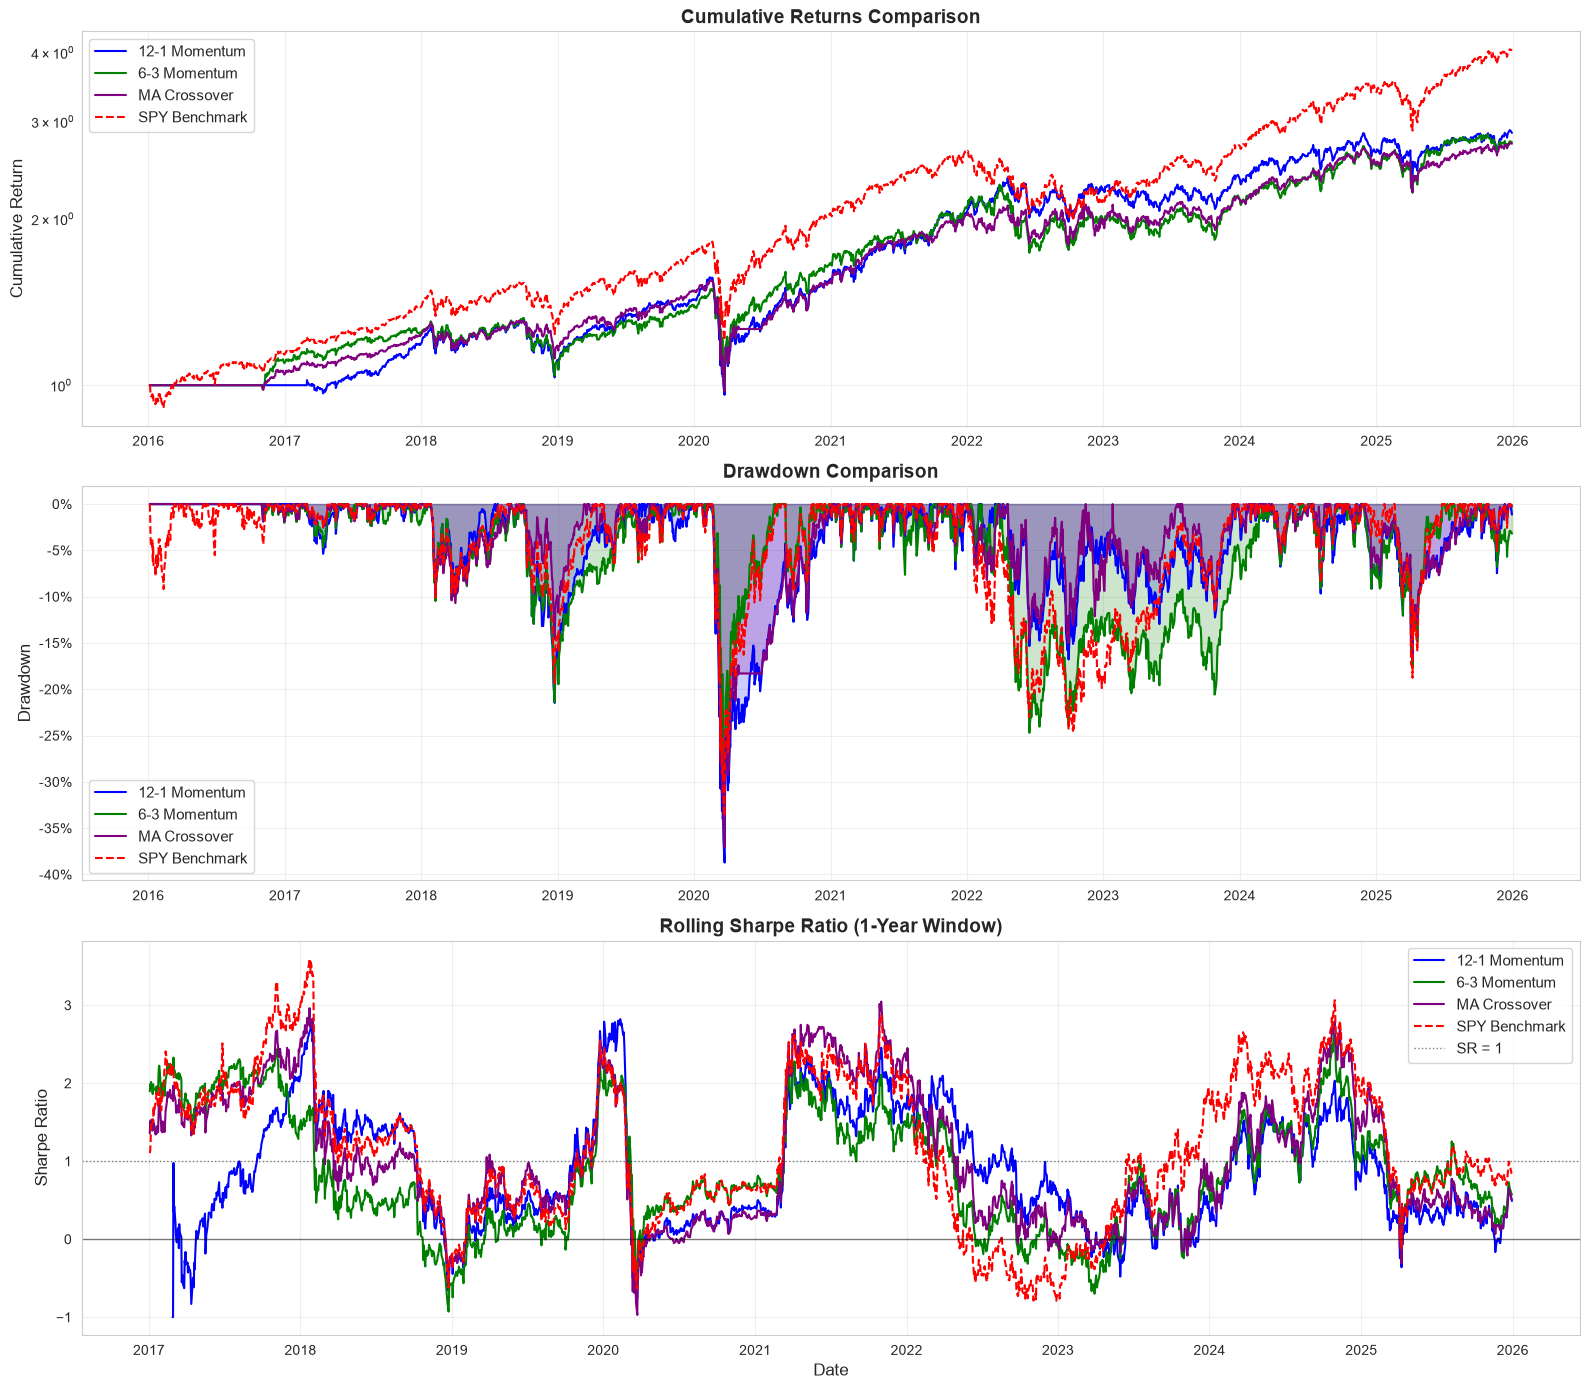

In [10]:
# Plot cumulative returns
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Cumulative returns
ax1 = axes[0]
ax1.plot(results_12_1.index, results_12_1['Cumulative_Returns'], 
         label='12-1 Momentum', linewidth=1.5, color='blue')
ax1.plot(results_6_3.index, results_6_3['Cumulative_Returns'], 
         label='6-3 Momentum', linewidth=1.5, color='green')
ax1.plot(results_ma.index, results_ma['Cumulative_Returns'], 
         label='MA Crossover', linewidth=1.5, color='purple')
ax1.plot(benchmark_cumulative.index, benchmark_cumulative, 
         label='SPY Benchmark', linewidth=1.5, color='red', linestyle='--')
ax1.set_title('Cumulative Returns Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Return', fontsize=12)
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Drawdown
ax2 = axes[1]
for results, label, color in [
    (results_12_1, '12-1 Momentum', 'blue'),
    (results_6_3, '6-3 Momentum', 'green'),
    (results_ma, 'MA Crossover', 'purple')
]:
    cumulative = results['Cumulative_Returns']
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    ax2.plot(results.index, drawdown, label=label, linewidth=1.5, color=color)
    ax2.fill_between(results.index, drawdown, 0, alpha=0.2, color=color)

# Benchmark drawdown
bench_dd = (benchmark_cumulative - benchmark_cumulative.expanding().max()) / benchmark_cumulative.expanding().max()
ax2.plot(benchmark_cumulative.index, bench_dd, 
         label='SPY Benchmark', linewidth=1.5, color='red', linestyle='--')

ax2.set_title('Drawdown Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Drawdown', fontsize=12)
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Rolling Sharpe ratio (252-day window)
ax3 = axes[2]
window = 252
for results, label, color in [
    (results_12_1, '12-1 Momentum', 'blue'),
    (results_6_3, '6-3 Momentum', 'green'),
    (results_ma, 'MA Crossover', 'purple')
]:
    returns_series = results['Returns'].dropna()
    rolling_sharpe = (returns_series.rolling(window).mean() * 252) / (returns_series.rolling(window).std() * np.sqrt(252))
    ax3.plot(returns_series.index, rolling_sharpe, label=label, linewidth=1.5, color=color)

# Benchmark rolling Sharpe
bench_rolling_sharpe = (benchmark_returns.rolling(window).mean() * 252) / (benchmark_returns.rolling(window).std() * np.sqrt(252))
ax3.plot(benchmark_returns.index, bench_rolling_sharpe, 
         label='SPY Benchmark', linewidth=1.5, color='red', linestyle='--')

ax3.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax3.axhline(1, color='black', linestyle=':', linewidth=1, alpha=0.5, label='SR = 1')
ax3.set_title('Rolling Sharpe Ratio (1-Year Window)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Sharpe Ratio', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(fontsize=11, loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
def calculate_period_returns(results, freq='ME'):
    """
    Calculate returns by period (monthly, quarterly).
    """
    returns = results['Returns'].copy()
    period_returns = (1 + returns).resample(freq).prod() - 1
    return period_returns

# Monthly returns
monthly_12_1 = calculate_period_returns(results_12_1, 'ME')
monthly_6_3 = calculate_period_returns(results_6_3, 'ME')
monthly_ma = calculate_period_returns(results_ma, 'ME')
monthly_bench = (1 + benchmark_returns).resample('ME').prod() - 1

# Quarterly returns
quarterly_12_1 = calculate_period_returns(results_12_1, 'QE')
quarterly_6_3 = calculate_period_returns(results_6_3, 'QE')
quarterly_ma = calculate_period_returns(results_ma, 'QE')
quarterly_bench = (1 + benchmark_returns).resample('QE').prod() - 1

print("\nMonthly Performance Summary (Last 12 Months)")
print("=" * 70)
monthly_summary = pd.DataFrame({
    '12-1 Momentum': monthly_12_1.iloc[-12:],
    '6-3 Momentum': monthly_6_3.iloc[-12:],
    'MA Crossover': monthly_ma.iloc[-12:],
    'SPY Benchmark': monthly_bench.iloc[-12:]
})
print(monthly_summary.to_string())

print("\nQuarterly Performance Summary (Last 8 Quarters)")
print("=" * 70)
quarterly_summary = pd.DataFrame({
    '12-1 Momentum': quarterly_12_1.iloc[-8:],
    '6-3 Momentum': quarterly_6_3.iloc[-8:],
    'MA Crossover': quarterly_ma.iloc[-8:],
    'SPY Benchmark': quarterly_bench.iloc[-8:]
})
print(quarterly_summary.to_string())


Monthly Performance Summary (Last 12 Months)
            12-1 Momentum  6-3 Momentum  MA Crossover  SPY Benchmark
Date                                                                
2025-01-31       0.047908      0.027646      0.030816       0.026856
2025-02-28      -0.013367      0.011470      0.006711      -0.012695
2025-03-31      -0.040710     -0.049795     -0.039330      -0.055719
2025-04-30      -0.006452     -0.006452     -0.024629      -0.008670
2025-05-31       0.031462      0.072451      0.032069       0.062845
2025-06-30       0.011934      0.028479      0.005946       0.051386
2025-07-31       0.022382      0.015423      0.020167       0.023031
2025-08-31       0.005090      0.009365      0.018521       0.020520
2025-09-30       0.020154      0.006012      0.015829       0.035620
2025-10-31      -0.007118     -0.000452     -0.005058       0.023838
2025-11-30      -0.014677     -0.013201      0.016074       0.001950
2025-12-31       0.025719     -0.002009      0.007218    

## Periodic returns

Aggregating daily returns into **monthly and quarterly** buckets gives a more digestible view of consistency and helps spot seasonal or regime patterns. The bar charts color winning periods green and losing periods red, with average return and hit rate annotated.

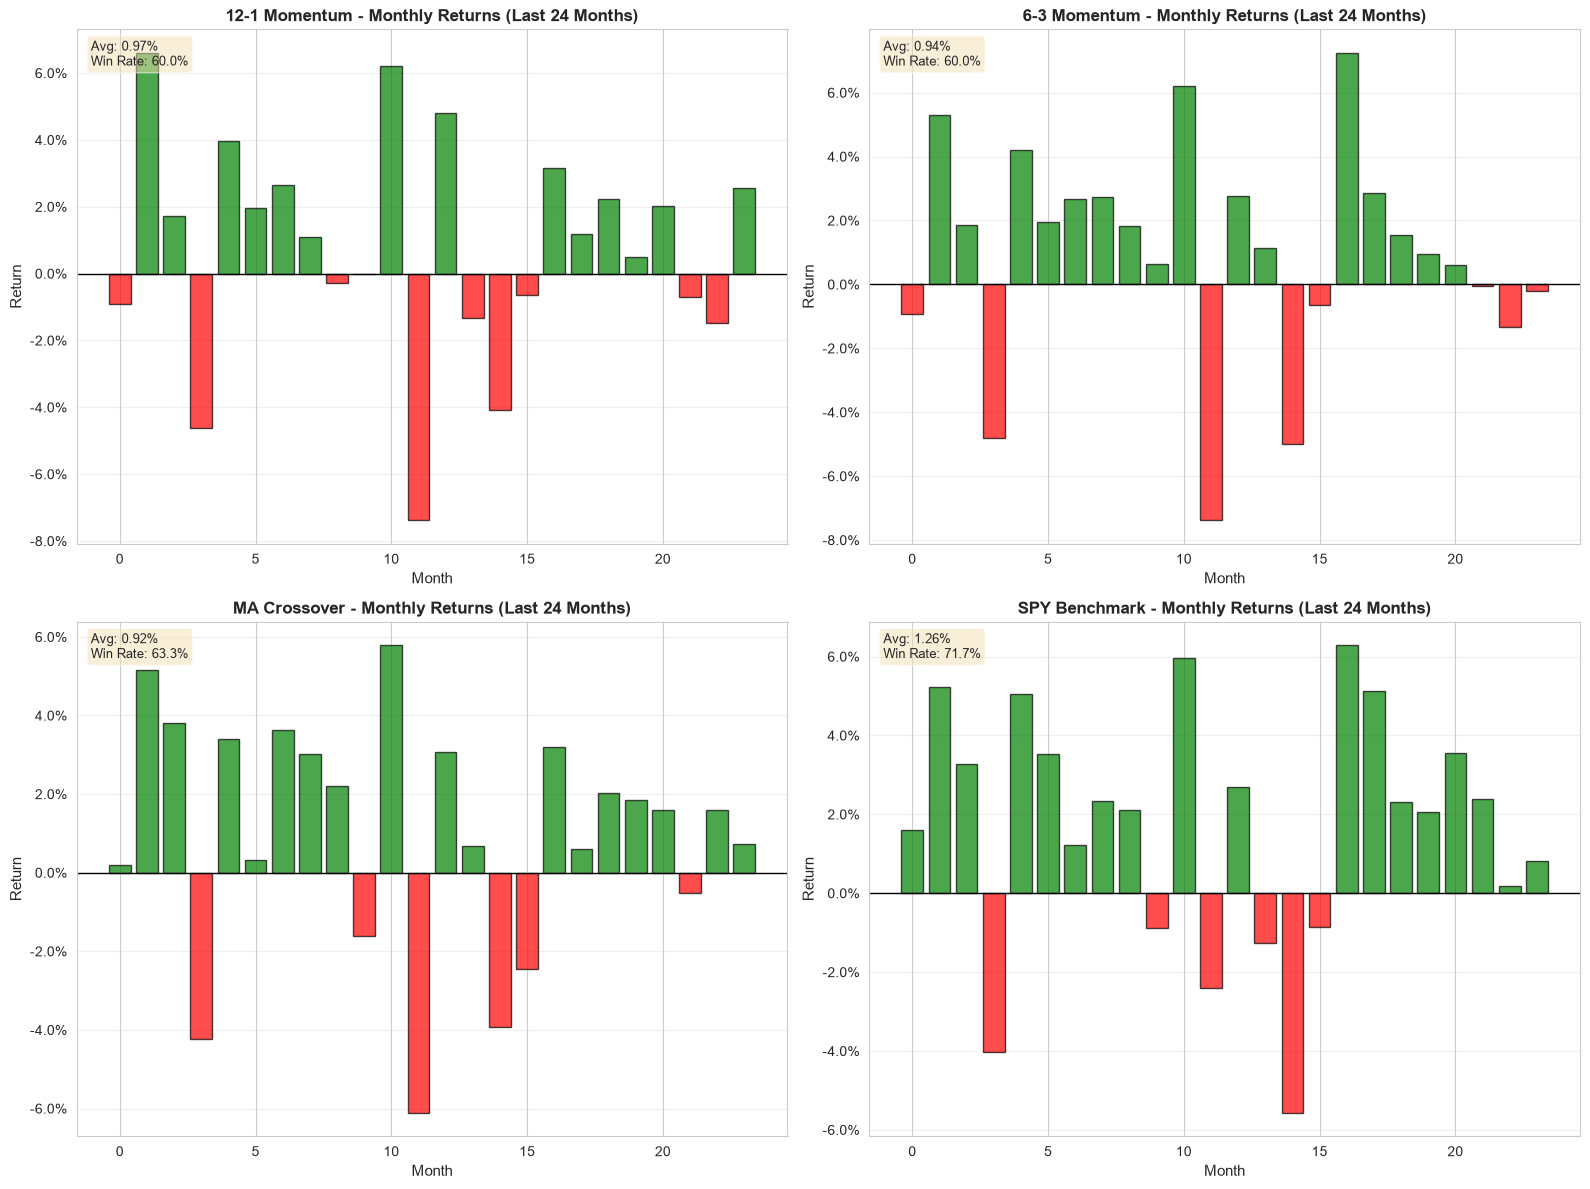

In [12]:
# Visualize monthly returns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategies = [
    ('12-1 Momentum', monthly_12_1, 'blue'),
    ('6-3 Momentum', monthly_6_3, 'green'),
    ('MA Crossover', monthly_ma, 'purple'),
    ('SPY Benchmark', monthly_bench, 'red')
]

for idx, (name, returns, color) in enumerate(strategies):
    ax = axes[idx // 2, idx % 2] # // (Floor Division); % (Modulo)
    
    # Bar chart of monthly returns
    colors_bars = ['green' if r > 0 else 'red' for r in returns.iloc[-24:]]
    ax.bar(range(len(returns.iloc[-24:])), returns.iloc[-24:], 
           color=colors_bars, alpha=0.7, edgecolor='black')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'{name} - Monthly Returns (Last 24 Months)', 
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Return', fontsize=11)
    ax.set_xlabel('Month', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax.grid(axis='y', alpha=0.3)
    
    # Stats
    avg_return = returns.mean()
    win_rate = (returns > 0).sum() / len(returns)
    ax.text(0.02, 0.98, f'Avg: {avg_return:.2%}\nWin Rate: {win_rate:.1%}',
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=9)

plt.tight_layout()
plt.show()

## Advanced risk-adjusted metrics

Sharpe treats upside and downside volatility alike and ignores the benchmark. These refinements each fix one blind spot:

$$\text{Information Ratio} = \frac{\mathbb{E}[R_p - R_b]}{\sigma(R_p - R_b)}, \qquad \text{Sortino} = \frac{\mu_p}{\sigma_{\text{downside}}}, \qquad \text{Calmar} = \frac{\mu_p}{|\text{MDD}|}.$$

- **Information Ratio** — active return per unit of *tracking error* vs the benchmark.
- **Sortino** — like Sharpe but penalizes only *downside* deviation, not upside.
- **Calmar** — return per unit of worst drawdown.
- **Beta / Alpha** — from the market regression $R_p = \alpha + \beta R_b + \varepsilon$: $\beta$ is systematic exposure, and **Jensen's alpha** is the annualized return left after stripping out that market exposure.

The negative Information Ratios and alphas here quantify the earlier observation: after costs, these strategies delivered *less* than their market exposure alone would predict.

In [13]:
def calculate_advanced_metrics(results, benchmark_returns):
    """
    Calculate advanced performance metrics.
    """
    returns = results['Returns'].dropna()
    
    # Information ratio (excess_return / std of excess_return)
    excess_returns = returns - benchmark_returns.loc[returns.index]
    ir = (excess_returns.mean() * 252) / (excess_returns.std() * np.sqrt(252))
    
    # Sortino ratio ((return - risk_free_rate) / downside deviation)
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside_std if downside_std > 0 else 0
    
    # Calmar ratio (return / max drawdown)
    ann_return = (returns.mean() * 252)
    cumulative = results['Cumulative_Returns']
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_dd = abs(drawdown.min())
    calmar = ann_return / max_dd if max_dd > 0 else 0
    
    # Beta (vs benchmark)
    # beta = Cov(asset_return, market_return) / Var(market_return)
    aligned_bench = benchmark_returns.loc[returns.index]
    covariance = returns.cov(aligned_bench)
    benchmark_var = aligned_bench.var()
    beta = covariance / benchmark_var if benchmark_var > 0 else 0
    
    # Alpha (annualized)
    # alpha = asset_return - risk_free-rate - beta(market_return - risk_free_rate)
    alpha = (returns.mean() - beta * aligned_bench.mean()) * 252
    
    return {
        'Information Ratio': ir,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Beta': beta,
        'Alpha': alpha
    }

# Calculate for all strategies
advanced_12_1 = calculate_advanced_metrics(results_12_1, benchmark_returns)
advanced_6_3 = calculate_advanced_metrics(results_6_3, benchmark_returns)
advanced_ma = calculate_advanced_metrics(results_ma, benchmark_returns)

advanced_comparison = pd.DataFrame({
    '12-1 Momentum': advanced_12_1,
    '6-3 Momentum': advanced_6_3,
    'MA Crossover': advanced_ma
}).T

print("\nAdvanced Risk-Adjusted Metrics")
print("=" * 90)
print(advanced_comparison.to_string())

print("\nMetric Definitions:")
print("• Information Ratio: Excess return per unit of tracking error")
print("• Sortino Ratio: Return per unit of downside deviation")
print("• Calmar Ratio: Return per unit of maximum drawdown")
print("• Beta: Systematic risk relative to benchmark")
print("• Alpha: Excess return after adjusting for beta")


Advanced Risk-Adjusted Metrics
               Information Ratio  Sortino Ratio  Calmar Ratio      Beta     Alpha
12-1 Momentum          -0.366627       0.767042      0.315805  0.882984 -0.015657
6-3 Momentum           -0.418017       0.773395      0.356685  0.882282 -0.019582
MA Crossover           -0.463836       0.770721      0.309569  0.797923 -0.009928

Metric Definitions:
• Information Ratio: Excess return per unit of tracking error
• Sortino Ratio: Return per unit of downside deviation
• Calmar Ratio: Return per unit of maximum drawdown
• Beta: Systematic risk relative to benchmark
• Alpha: Excess return after adjusting for beta
